# Задание Light

1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.

## Подготовка

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [ ]:
# Загрузим датасет из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распакуем архив в папку writers
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Получим списка файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    # Выделяем имя класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатываем
    if m:

        # Получим имя класса
        class_name = m[1]

        # Получим имя выборки
        subset_name = m[2].lower()

        # Проверим тип выборки
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатываем
        if is_train or is_test:

            # Добавляем новый класс, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)

                # Инициализируем соответствующих классу строки текста
                text_train.append('')
                text_test.append('')

            # Найдем индекс класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')

            # Откроем файл на чтение
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:

                # Загрузим содержимого файла в строку
                text = f.read()
            # Определим выборку, куда будет добавлено содержимое
            subset = text_train if is_train else text_test

            # Добавим текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие", тестовая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.


<>:12: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_13472/2214232407.py:12: SyntaxWarning: invalid escape sequence '\('
  m = re.match('\((.+)\) (\S+)_', file_name)


Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.


In [ ]:
# Определим количество классов
CLASS_COUNT = len(CLASS_LIST)

In [ ]:
# Выведем прочитанные классы текстов
print(CLASS_LIST)

['Клиффорд_Саймак', 'Макс Фрай', 'О. Генри', 'Стругацкие', 'Булгаков', 'Рэй Брэдберри']


In [ ]:
# Посчитаем количество текстов в обучающей выборке
print(len(text_train))

6


In [ ]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):                   # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')           # Выведем имя класса
    print(f'  train: {text_train[cls][:200]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls][:200]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: Макс Фрай
  train:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне ежедневно снится какая-то дичь! – сердито сказал я Джуффину. – Сглазили они меня, что ли? А собственно, по
  test :  ﻿Слишком много кошмаров    Когда балансируешь над пропастью на узкой, скользкой от крови доске, ответ на закономерный вопрос: «Как меня сюда занесло?» – вряд ли принесёт практическую пользу. Зато пои

Класс: О. Генри
  train:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная красавица в сурово храним

In [ ]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## Решение

In [ ]:
import pandas as pd
import tensorflow

np.random.seed(42)
tensorflow.random.set_seed(42)

epochs = 100
batch_size = 512

results = []

# Функция разбиения текста на окна
def split_sequence(sequence, win_size, hop):
    result = []

    for i in range(0, len(sequence) - win_size + 1, hop):
        result.append(sequence[i:i + win_size])

    return result

# функция создания обучающей и тестовой выборки
def vectorize_sequence(seq_list, win_size, hop):
    x = []
    y = []

    class_count = len(seq_list)

    for class_index in range(class_count):
        windows = split_sequence(seq_list[class_index], win_size, hop)

        x += windows
        y += [utils.to_categorical(class_index, class_count)] * len(windows)

    return np.array(x), np.array(y)


# функция подготовки данных
def prepare_data(vocab_size, win_size, win_hop):
    tokenizer = Tokenizer(num_words=vocab_size, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff', lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

    tokenizer.fit_on_texts(text_train)

    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

    x_train, y_train = vectorize_sequence(seq_train, win_size, win_hop)
    x_test, y_test = vectorize_sequence(seq_test, win_size, win_hop)

    return x_train, y_train, x_test, y_test


# создание модели из методички #13:
# Embedding(50) + BLSTM(8)x2 + GRU(16)x2 + Dense(200)
def create_model(vocab_size, win_size):
    model = Sequential()

    model.add(Embedding(vocab_size, 50, input_length=win_size))

    model.add(SpatialDropout1D(0.4))
    model.add(BatchNormalization())

    model.add(Bidirectional(LSTM(8, return_sequences=True)))
    model.add(Bidirectional(LSTM(8, return_sequences=True)))

    model.add(Dropout(0.3))
    model.add(BatchNormalization())

    model.add(GRU(16, return_sequences=True, reset_after=True))
    model.add(GRU(16, reset_after=True))

    model.add(Dropout(0.3))
    model.add(BatchNormalization())

    model.add(Dense(200, activation='relu'))

    model.add(Dropout(0.3))
    model.add(BatchNormalization())

    model.add(Dense(CLASS_COUNT, activation='softmax'))

    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def plot_history(history, vocab_size, win_size, win_hop):
    plt.figure(figsize=(5, 3))
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.plot(history.history['val_accuracy'], label='Точность на проверке')
    plt.title(
        f'График точности\n'
        f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
    )
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(5, 3))
    plt.plot(history.history['loss'], label='Ошибка на обучении')
    plt.plot(history.history['val_loss'], label='Ошибка на проверке')
    plt.title(
        f'График ошибки\n'
        f'VOCAB_SIZE={vocab_size}, WIN_SIZE={win_size}, WIN_HOP={win_hop}'
    )
    plt.xlabel('Эпоха')
    plt.ylabel('Ошибка')
    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.2201 - loss: 2.0506 - val_accuracy: 0.2929 - val_loss: 1.7458
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.3338 - loss: 1.7447 - val_accuracy: 0.2929 - val_loss: 1.7523
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.4535 - loss: 1.4097 - val_accuracy: 0.1611 - val_loss: 1.8349
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.5259 - loss: 1.2199 - val_accuracy: 0.1611 - val_loss: 1.9254
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.5738 - loss: 1.0891 - val_accuracy: 0.1656 - val_loss: 1.9795
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.6253 - loss: 0.9441 - val_accuracy: 0.1816 - val_loss: 2.0580
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.6614 - loss: 0.8957 - val_accuracy: 0.2924 - val_loss: 3.5882
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.6261 - loss: 0.9742 - 

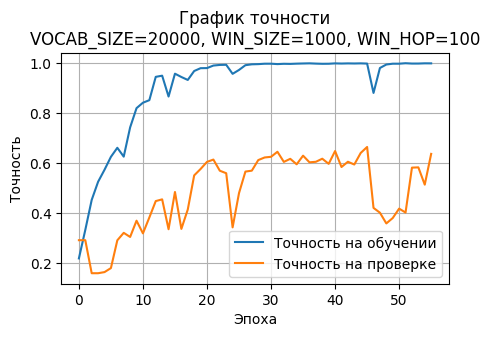

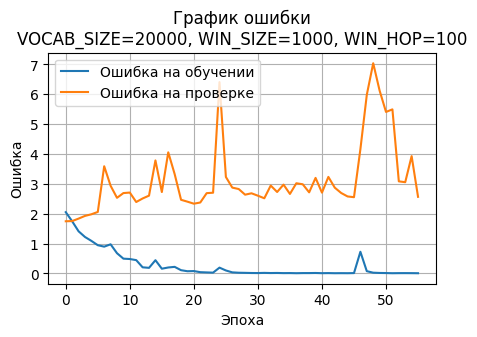

Лучшая точность: 0.6646724343299866


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

results = []

VOCAB_SIZE = 20000
WIN_SIZE = 1000
WIN_HOP = 100

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 350ms/step - accuracy: 0.2383 - loss: 1.9938 - val_accuracy: 0.2929 - val_loss: 1.7494
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 305ms/step - accuracy: 0.3425 - loss: 1.7271 - val_accuracy: 0.2929 - val_loss: 1.7596
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.4337 - loss: 1.4591 - val_accuracy: 0.1611 - val_loss: 1.8159
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.4881 - loss: 1.2768 - val_accuracy: 0.0739 - val_loss: 1.8865
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 296ms/step - accuracy: 0.5098 - loss: 1.2330 - val_accuracy: 0.0761 - val_loss: 1.9486
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.5738 - loss: 1.0892 - val_accuracy: 0.0800 - val_loss: 2.0677
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - accuracy: 0.6115 - loss: 1.0013 - val_accuracy: 0.1252 - val_loss: 2.0661
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.6456 - loss: 0.9263 - 

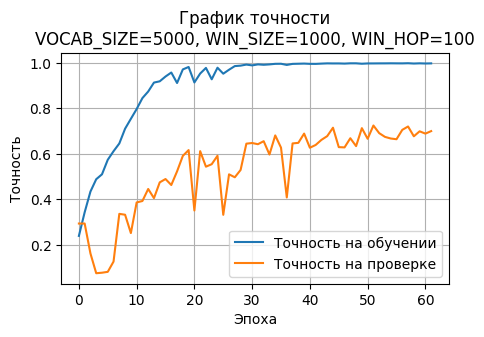

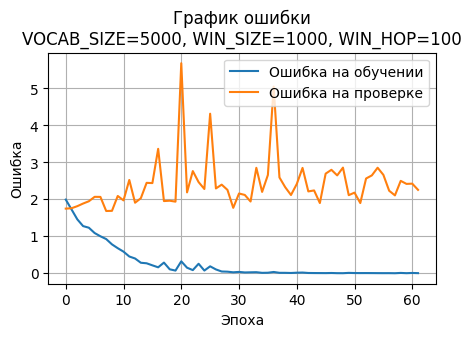

Лучшая точность: 0.7247980833053589


In [ ]:
VOCAB_SIZE = 5000
WIN_SIZE = 1000
WIN_HOP = 100

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 316ms/step - accuracy: 0.2433 - loss: 1.9973 - val_accuracy: 0.2929 - val_loss: 1.7417
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.3443 - loss: 1.7020 - val_accuracy: 0.2929 - val_loss: 1.7471
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.4413 - loss: 1.4110 - val_accuracy: 0.3074 - val_loss: 1.6817
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.4831 - loss: 1.2709 - val_accuracy: 0.3014 - val_loss: 1.8722
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.5405 - loss: 1.1549 - val_accuracy: 0.3069 - val_loss: 2.0100
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.5713 - loss: 1.0940 - val_accuracy: 0.2931 - val_loss: 2.4359
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.6286 - loss: 0.9441 - val_accuracy: 0.2970 - val_loss: 3.2429
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.6674 - loss: 0.8456 - 

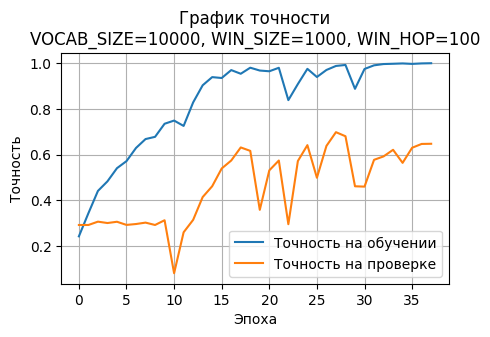

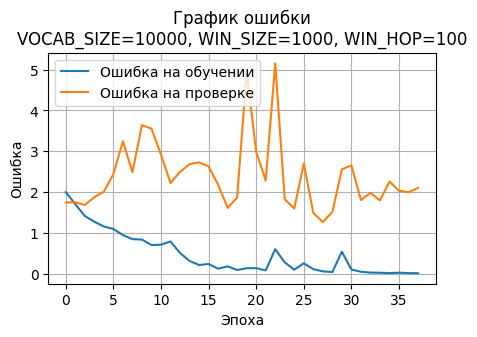

Лучшая точность: 0.6974274516105652


In [ ]:
VOCAB_SIZE = 10000
WIN_SIZE = 1000
WIN_HOP = 100

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.2337 - loss: 2.0097 - val_accuracy: 0.2929 - val_loss: 1.7441
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.3507 - loss: 1.6969 - val_accuracy: 0.2929 - val_loss: 1.7461
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.4688 - loss: 1.3739 - val_accuracy: 0.1494 - val_loss: 1.7355
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.5478 - loss: 1.1442 - val_accuracy: 0.3153 - val_loss: 1.8996
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.5977 - loss: 1.0213 - val_accuracy: 0.3012 - val_loss: 2.8712
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.6719 - loss: 0.8706 - val_accuracy: 0.2577 - val_loss: 1.8293
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.7365 - loss: 0.6769 - val_accuracy: 0.3222 - val_loss: 2.4863
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.7982 - loss: 0.5501 - 

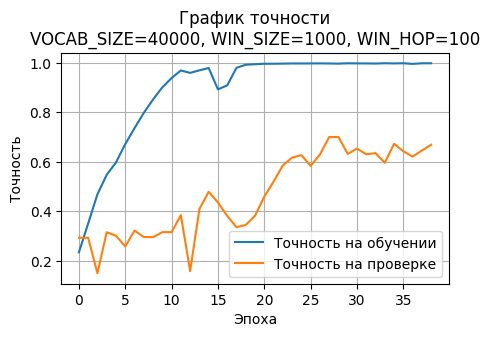

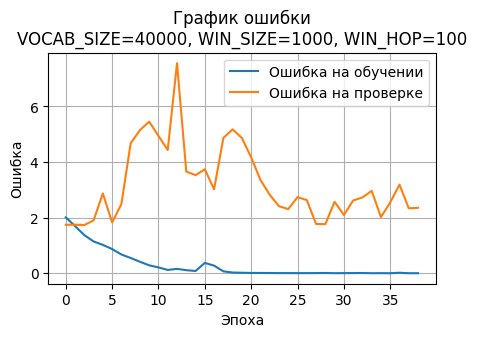

Лучшая точность: 0.7007179260253906


In [ ]:
VOCAB_SIZE = 40000
WIN_SIZE = 1000
WIN_HOP = 100

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.2853 - loss: 1.8674 - val_accuracy: 0.2923 - val_loss: 1.7420
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.4456 - loss: 1.4067 - val_accuracy: 0.2923 - val_loss: 2.0441
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.5006 - loss: 1.2774 - val_accuracy: 0.2926 - val_loss: 4.0055
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.5854 - loss: 1.0807 - val_accuracy: 0.3459 - val_loss: 2.6694
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.7141 - loss: 0.7520 - val_accuracy: 0.3757 - val_loss: 1.7070
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.8306 - loss: 0.4774 - val_accuracy: 0.4042 - val_loss: 2.2260
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.7099 - loss: 0.8639 - val_accuracy: 0.2575 - val_loss: 1.6828
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.8240 - loss: 0.5034 - 

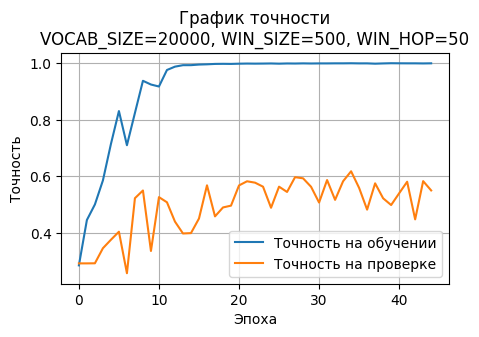

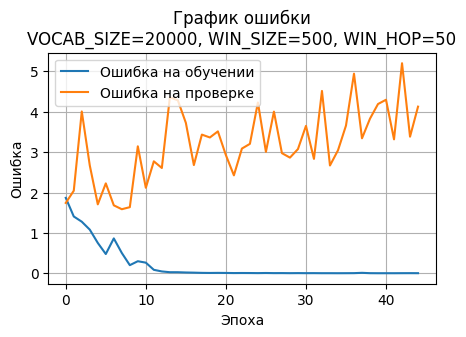

Лучшая точность: 0.6177850365638733


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 500
WIN_HOP = 50

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 607ms/step - accuracy: 0.1971 - loss: 2.1596 - val_accuracy: 0.2939 - val_loss: 1.7459
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 526ms/step - accuracy: 0.2672 - loss: 1.9193 - val_accuracy: 0.2939 - val_loss: 1.7379
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 546ms/step - accuracy: 0.3358 - loss: 1.7460 - val_accuracy: 0.2939 - val_loss: 1.7339
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 552ms/step - accuracy: 0.3952 - loss: 1.5783 - val_accuracy: 0.2939 - val_loss: 1.7299
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 553ms/step - accuracy: 0.4666 - loss: 1.3887 - val_accuracy: 0.3280 - val_loss: 1.7020
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 629ms/step - accuracy: 0.5032 - loss: 1.2481 - val_accuracy: 0.1629 - val_loss: 1.7898
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 535ms/step - accuracy: 0.5638 - loss: 1.1057 - val_accuracy: 0.2939 - val_loss: 1.7701
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 532ms/step - accuracy: 0.6217 - loss: 0.9680 - v

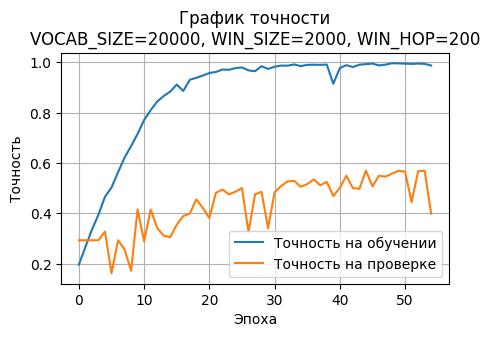

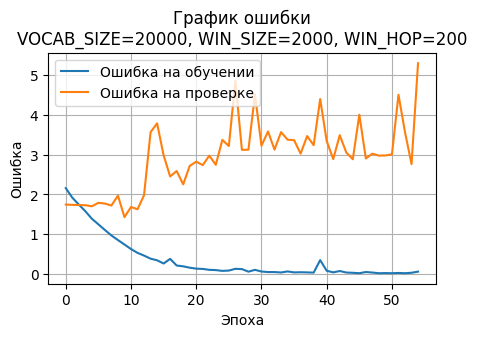

Лучшая точность: 0.5703077912330627


In [ ]:
VOCAB_SIZE = 20000
WIN_SIZE = 2000
WIN_HOP = 200

x_train, y_train, x_test, y_test = prepare_data(VOCAB_SIZE, WIN_SIZE, WIN_HOP)

model = create_model(VOCAB_SIZE, WIN_SIZE)

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_test, y_test), callbacks=[early_stop], verbose=1)

plot_history(history, VOCAB_SIZE, WIN_SIZE, WIN_HOP)

best_val_accuracy = max(history.history['val_accuracy'])

print('Лучшая точность:', best_val_accuracy)

results.append({
    'VOCAB_SIZE': VOCAB_SIZE,
    'WIN_SIZE': WIN_SIZE,
    'WIN_HOP': WIN_HOP,
    'Точность на обучении': history.history['accuracy'][-1],
    'Точность на проверке': history.history['val_accuracy'][-1],
    'Лучшая точность на проверке': best_val_accuracy,
    'Ошибка на обучении': history.history['loss'][-1],
    'Ошибка на проверке': history.history['val_loss'][-1],
    'Лучшая ошибка на проверке': min(history.history['val_loss'])
})

results_df = pd.DataFrame(results)

In [ ]:
display(results_df)

,VOCAB_SIZE,WIN_SIZE,WIN_HOP,Точность на обучении,Точность на проверке,Лучшая точность на проверке,Ошибка на обучении,Ошибка на проверке,Лучшая ошибка на проверке
0,20000,1000,100,0.998186,0.637152,0.664672,0.006011,2.563949,1.745787
1,5000,1000,100,0.998583,0.700120,0.724798,0.005230,2.256466,1.685158
2,10000,1000,100,0.998016,0.646874,0.697427,0.009197,2.099905,1.262317
3,40000,1000,100,0.999093,0.669309,0.700718,0.003751,2.353584,1.735516
4,20000,500,50,0.999292,0.550086,0.617785,0.003172,4.125125,1.586260
5,20000,2000,200,0.987489,0.399215,0.570308,0.057888,5.303282,1.429264
